## Libraries

In [276]:
import numpy as np
import torch 
import torch.nn as nn 
import scipy.io 
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

## Load Data

In [277]:
data = scipy.io.loadmat('/Users/ramtarun/Desktop/Cambridge/Indirect-Noise-in-Nozzles/Data/Data_PINN_ff0.01He0N551_subsonic.mat')

## Data Preprocessing

In [278]:
U = torch.zeros((551,4))
U[:,0] = torch.from_numpy(data['eta'])
U[:,1] = torch.from_numpy(data['pi_p'])
U[:,2] = torch.from_numpy(data['pi_m'])
U[:,3] = torch.from_numpy(data['sig'])

eta = U[:, 0]
pi_p = U[:, 1]
pi_m = U[:, 2]
sig = U[:, 3]

N1 = eta.shape[0]

D = torch.from_numpy(data['D'])
M = torch.from_numpy(data['M'])
u = torch.from_numpy(data['ubar'])
dMdx = torch.from_numpy(data['dMdx'])
dudx = torch.from_numpy(data['dudx'])
alpha = torch.from_numpy(data['alp'])
eta1 = torch.from_numpy(data['eta'])    

#print(N1)

meanflow = torch.zeros((N1,7))
meanflow[:,0] = D
meanflow[:,1] = M
meanflow[:,2] = u
meanflow[:,3] = dMdx
meanflow[:,4] = dudx
meanflow[:,5] = alpha
meanflow[:,6] = eta1

#print(meanflow)

he = torch.tensor([0.00])
HE = torch.tile(he, (1,N1)) 
He = HE.flatten()[:,None]
ETA = eta.flatten()[:, None]
UU = U[:, 1:4]



## Split Dataset into Training and Testing Dataset

In [279]:
#ETA_train.requires_grad = True
split_ratio = 0.85
He_train, He_test = train_test_split(He, train_size = split_ratio, shuffle = True)
Eta_train, Eta_test, UU_train, UU_test = train_test_split(ETA, UU, train_size = split_ratio, shuffle=False)
#print(UU)

meanflow_train, meanflow_test = train_test_split(meanflow, train_size = split_ratio, shuffle=False)

## Visualizing the Training Dataset

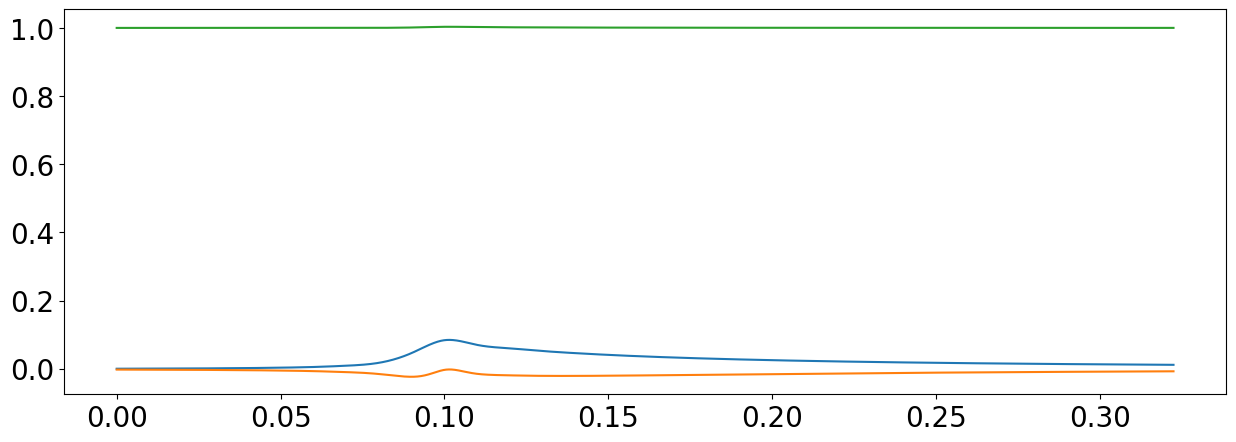

In [280]:
plt.rcParams["figure.figsize"] = (15,5)
plt.rcParams["font.size"]  = 20
plt.plot(Eta_train, UU_train)

In [281]:
Eta_train.requires_grad = True
Eta_test.requires_grad = True
UU_train.requires_grad = True
UU_test.requires_grad = True

## Governing Partial Differential Equation Estimation

In [282]:
def RHS_f(y, baseflow, f):
    
    pi_p, pi_m, sig = torch.unbind(y,axis=1)

    D = baseflow[:,0]
    M = baseflow[:,1]
    u = baseflow[:,2]
    dMdx = baseflow[:,3]
    dudx = baseflow[:,4]
    alpha = baseflow[:,5]
    eta1 = baseflow[:,6]    
    
    He = 0#a constant input

    gamma = 1.4#constant
    
    Msq = torch.square(M)

    Lambda = 1 + Msq * (gamma-1)/2
    zeta = f*gamma*Msq - 2*torch.tan(alpha)
    C1= ((gamma - 1)*(1-Msq)*f)/(2*Lambda*zeta)
    Ca = -C1*M*u*dMdx*(2-(2*Msq/(1-Msq)) - (2*gamma*Msq*(-2*f*Lambda - (gamma-1)/gamma *zeta)/(2*Lambda*zeta)))
    Ff = -(dudx + (4*f*u/(2*D)))
    
    denom = (Msq*u - u + C1*Msq *u + C1*Msq*Msq*gamma*u) #M**4
    vrh_p = M*(2*(1-M) + C1*M*(M-2+M*gamma*(1-2*M)))/(2*denom)
    vrh_m = -M*(2*(1+M) + C1*M*(M+2+M*gamma*(1+2*M)))/(2*denom)
    vkp_p = Msq*C1*(2+M*(gamma-1))/(2*denom)
    vkp_m = Msq*C1*(2-M*(gamma-1))/(2*denom)
    vth_p = C1*M*(M*(1+gamma) + M**2*(1-gamma) - 2)/denom
    vth_m = C1*M*(M*(1+gamma) - M**2*(1-gamma) + 2)/denom
    vsig = -(C1*Msq*(1+gamma*Msq) + Msq - 1)/denom
    calM = dMdx/(2*M)
    kp_p = (gamma - 1) + (2/M)
    kp_m = (gamma - 1) - (2/M)
    Gm_p = M*(Ca*(M + 1) + Ff*M*(C1*gamma*M*Msq + M + (1 - C1*Msq)))/(2*denom)
    Gm_m = M*(Ca*(M - 1) - Ff*M*(C1*gamma*M*Msq + M - (1 - C1*Msq)))/(2*denom)
    Ups = (Ca*(Msq - 1) - C1*Ff*Msq*Msq *(1+gamma))/denom
    
#     eq1 = - (2*np.pi*1j*He*vrh_p + Gm_m*kp_m + calM)*pi_p + (2*np.pi*1j*He*vkp_p + Gm_m*kp_p + calM)*pi_m - Gm_m*sig
#     eq2 = - (2*np.pi*1j*He*vkp_m + Gm_p*kp_m - calM)*pi_p - (2*np.pi*1j*He*vrh_m + Gm_p*kp_p + calM)*pi_m - Gm_m*sig
#     eq3 = - (2*np.pi*1j*He*vth_p + Ups*kp_m)*pi_p - (2*np.pi*1j*He*vth_m + Ups*kp_p)*pi_m - (2*np.pi*1j*He*vsig + Ups)*sig
#     eq1 = - tf.multiply((Gm_m*kp_m + calM),pi_p) + tf.multiply(( Gm_m*kp_p + calM),pi_m) - tf.multiply(Gm_m,sig)

    eq1 =  (Gm_m*kp_m + calM)*pi_p + ( Gm_m*kp_p - calM)*pi_m + Gm_m*sig
    eq2 =  (Gm_p*kp_m - calM)*pi_p + ( Gm_p*kp_p + calM)*pi_m + Gm_p*sig
    eq3 =  (Ups*kp_m)*pi_p + ( Ups*kp_p)*pi_m + (Ups)*sig
    
    return torch.stack([-eq1, -eq2, -eq3], axis=1)

## Hyperparameters for Tuning the model

In [283]:
#torch.cuda.manual_seed(22)
layers = np.array([2, 3, 3, 3, 3, 4, 4, 4, 4, 4, 3, 3, 3]) # Number of nodes in each layer of Neural Networks
epochs= 500
learning_rate=1e-4

## Deep Neural Netowrks 
    DNN architeecture is used to predict the dependant variables of the PDE. 

In [284]:
# Neural Network for Predicting the pi+, pi-, and si.

class NN(nn.Module):
    def __init__(self):
        super().__init__()

        self.layers = layers
        'activation function'
        self.activation = nn.Tanh()
    
        'Initialize neural network as a list using nn.Modulelist'  
        self.linears = nn.ModuleList([nn.Linear(self.layers[i], self.layers[i+1]) for i in range(len(self.layers)-1)])
    
        'Xavier Normal Initialization'
        for i in range(len(self.layers)-1):
            nn.init.xavier_normal_(self.linears[i].weight.data, gain=1.0)
            # set biases to zero
            nn.init.zeros_(self.linears[i].bias.data)

    def forward(self, X):
        if torch.is_tensor(X) != True:         
            X = torch.from_numpy(X) 
        a = X.type(torch.float32)
        for i in range(len(self.layers) - 2):
            z = self.linears[i](a)
            a = self.activation(z)
        a = self.linears[-1](a)
        return a

## Physics Informed Neural Networks 
    Predicted variables from the DNN, are then trained by minimizing a loss function, which is obtained by imposing the physics and constraints. 

In [285]:
# Physics informed Neural Network 
f = torch.empty(1)
lda = torch.tensor([0.0001])

class PINN(nn.Module):
    def __init__(self):
        super().__init__()

        self.loss_function = nn.MSELoss(reduction ='mean')
        'Initialize our new parameters i.e.f (Inverse problem)' 
        self.f = torch.tensor([f], requires_grad=True).type(torch.float32)
        nn.init.zeros_(self.f)
        'Register f to optimize'
        self.f = nn.Parameter(self.f)
        'Initialize iterator'
        self.iter = 0
        'Call our DNN'
        self.dnn = NN()
        'Register our new parameter'
        self.dnn.register_parameter('f', self.f)  

        'Regularisation Constant'
        self.lda = torch.tensor([lda])

    def loss_data(self, X, UU):
        loss_u = self.loss_function(self.dnn(X), UU)
        return loss_u
    
    def loss_residual(self, X, meanflow):
        f = self.f
        g = torch.clone(X)
        R = self.dnn(g)
        GR = RHS_f(R, meanflow, f)
        dr_dn = torch.autograd.grad(R,g,torch.ones_like(R), retain_graph=True, create_graph=True)[0]
        pde = dr_dn[:, 1:] + GR
        return torch.mean(pde**2)
    
    def Loss(self, X, UU, meanflow):
        loss_data = self.loss_data(X, UU)
        loss_residual = self.loss_residual(X, meanflow)
        return loss_data + self.lda*loss_residual
    
    
    'test neural network'
    def test(self, X_test, UU_test):
                
        u_pred = self.dnn(X_test)
        
        error_vec = torch.linalg.norm((UU_test-u_pred),2)/torch.linalg.norm(UU_test,2)        # Relative L2 Norm of the error (Vector)

        fric_f = self.f

        print('f_real = [0.01], f_PINN = [%.5f], Validation Loss = [%.5f] ' %(self.f.item(), error_vec.detach()))

        return

In [286]:
N_train = torch.cat([He_train, Eta_train],1)
N_test = torch.cat([He_test, Eta_test],1)
PINN_model = PINN()
params = list(PINN_model.parameters())
#optimizer = torch.optim.LBFGS(params, learning_rate, 
                              #max_iter = epochs, 
                              #max_eval = None, 
                              #tolerance_grad = 1e-11, 
                              #tolerance_change = 1e-11, 
                              #history_size = 100, 
                              #line_search_fn = 'strong_wolfe')
optimizer = torch.optim.Adam(params, lr = learning_rate, amsgrad = False)
criterion = nn.MSELoss()

In [287]:
losses = {}
ff = {}
batch_size = 10
for i in range(epochs):
    running_loss = 0.0
    for j in range(0, N_train.shape[0], batch_size):
        X_batch = N_train[j:j+batch_size]
        UU_batch = UU_train[j:j+batch_size]
        meanflow_batch = meanflow_train[j:j+batch_size]
        optimizer.zero_grad()
        loss = PINN_model.Loss(X_batch, UU_batch, meanflow_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch_size
    epoch_loss = running_loss / N_train.shape[0]
    losses[i]=(epoch_loss)
    ff[i] = PINN_model.f.item()
    if i == epochs-1:
        print(f"Epoch {i+1}/{epochs} - Loss: {epoch_loss:.6f}")
    elif (i+1) % (epochs//10) == 0:
        print(f"Epoch {i+1}/{epochs} - Loss: {epoch_loss:.6f}")

Epoch 50/500 - Loss: 0.000113
Epoch 100/500 - Loss: 0.000098
Epoch 150/500 - Loss: 0.000092
Epoch 200/500 - Loss: 0.000088
Epoch 250/500 - Loss: 0.000084
Epoch 300/500 - Loss: 0.000081
Epoch 350/500 - Loss: 0.000078
Epoch 400/500 - Loss: 0.000076
Epoch 450/500 - Loss: 0.000075
Epoch 500/500 - Loss: 0.000075


In [292]:
R_pred = PINN_model.dnn(N_train)

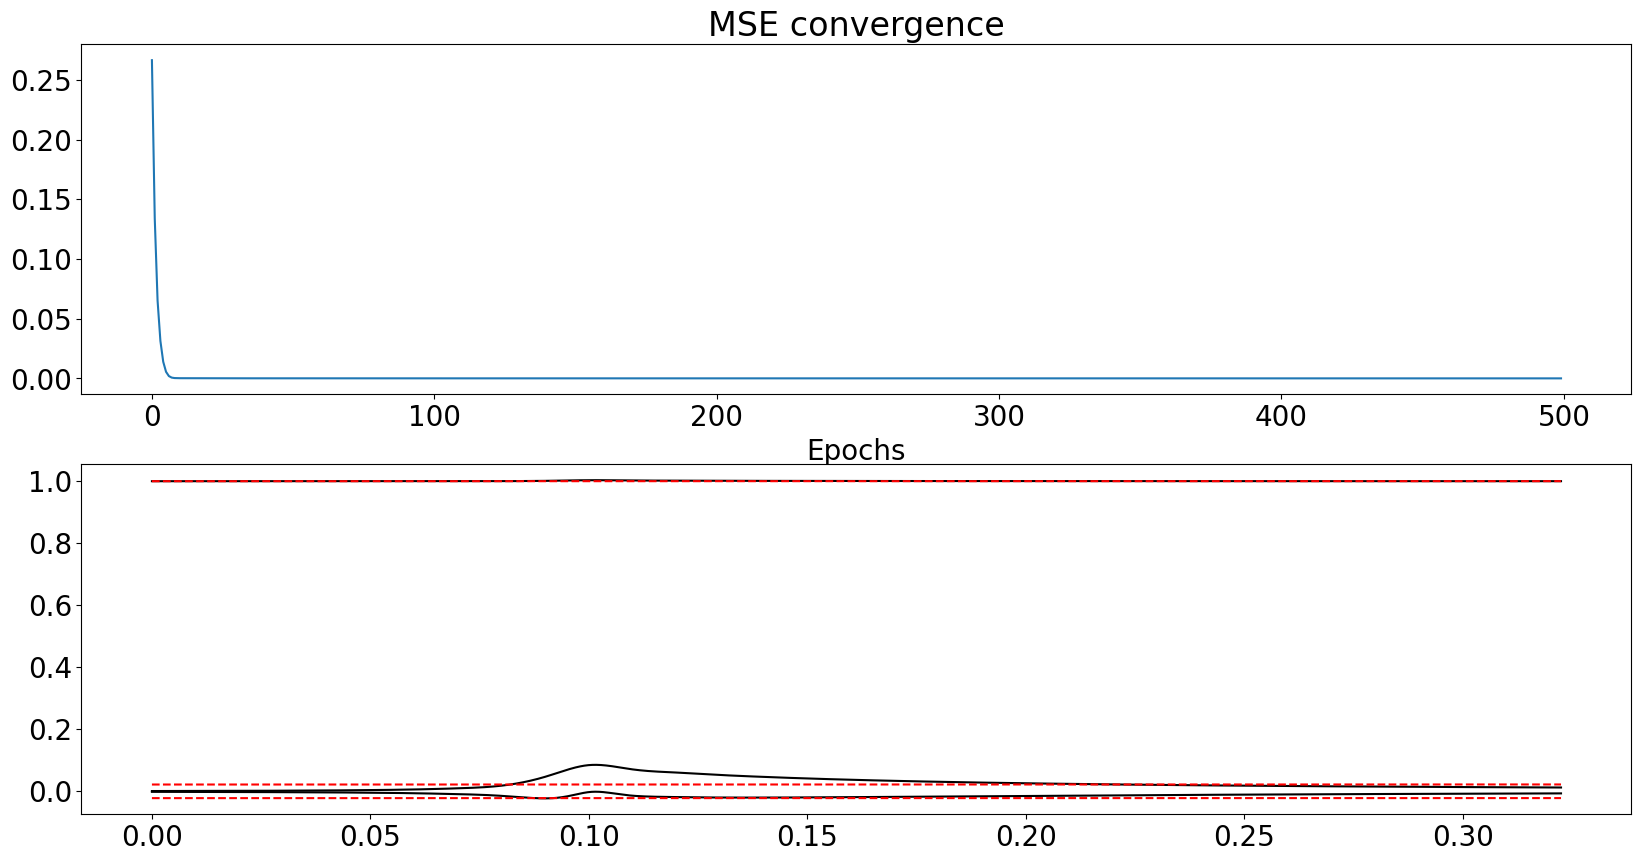

In [293]:
plt.rcParams["figure.figsize"] = (20, 10)
plt.rcParams["font.size"]  = 20
plt.subplot(2,1,1)
plt.plot(losses.keys(), losses.values())
plt.title('MSE convergence')
plt.xlabel('Epochs')
plt.subplot(2,1,2)
plt.plot(Eta_train.detach().cpu(), UU_train.detach().cpu(), 'black')
plt.plot(Eta_train.detach().cpu(),R_pred.detach().cpu(), 'r--')



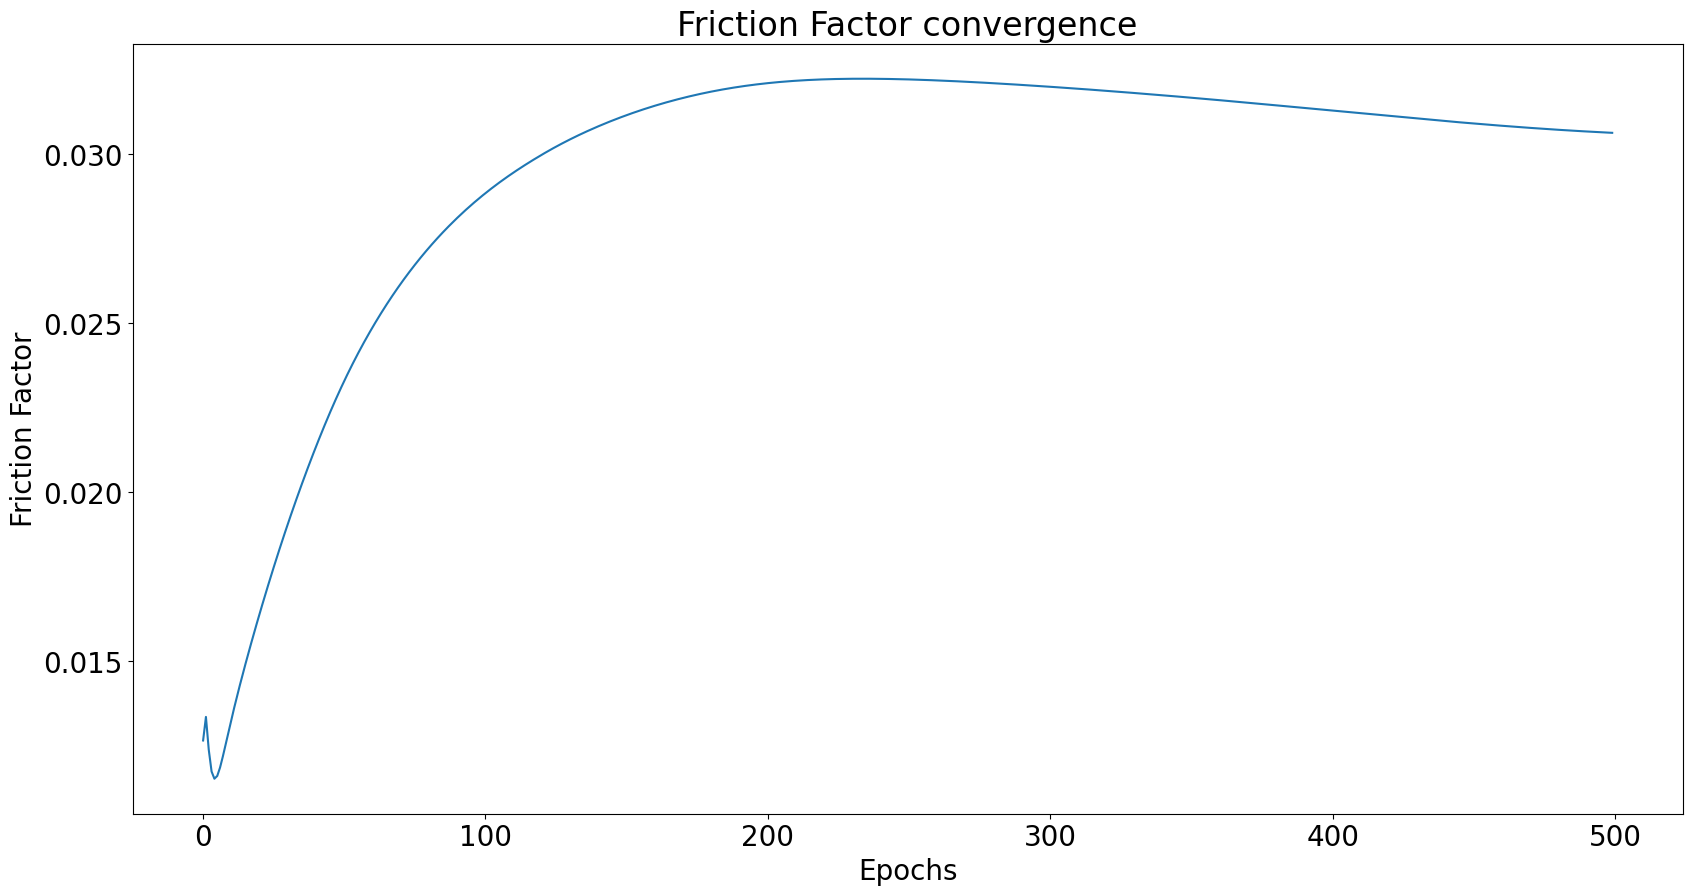

In [290]:
plt.rcParams["figure.figsize"] = (20, 10)
plt.rcParams["font.size"]  = 20
plt.title('Friction Factor convergence')
plt.xlabel('Epochs')
plt.ylabel('Friction Factor')
plt.plot(ff.keys(), ff.values())

In [291]:
PINN_model.test(N_test, UU_test)

f_real = [0.01], f_PINN = [0.03062], Validation Loss = [0.02531] 
